In [0]:
flights_df = spark.table("flights_delta")
bookings_df = spark.table("bookings_delta")
preferences_df = spark.table("preferences_delta")

flights_df.show(5)
bookings_df.show(5)
preferences_df.show(5)

+---------+---------+---------+---------+--------+---------+
|flight_id|  airline|from_city|  to_city|duration|   status|
+---------+---------+---------+---------+--------+---------+
|     F101|   Indigo|Hyderabad|    Delhi|     140|  On Time|
|     F102|Air India|   Mumbai|  Chennai|     120|  Delayed|
|     F103|  Vistara|Bangalore|Hyderabad|      90|  On Time|
|     F104|   Indigo|    Delhi|   Mumbai|     130|Cancelled|
|     F105|Air India|  Chennai|Bangalore|      80|  On Time|
+---------+---------+---------+---------+--------+---------+
only showing top 5 rows
+----------+---------+--------------+---------------+------------+------------+
|booking_id|flight_id|passenger_name|   travel_class|ticket_price|booking_date|
+----------+---------+--------------+---------------+------------+------------+
|     B1001|     F101|  Rahul Sharma|        Economy|        8500|  2026-06-01|
|     B1002|     F101|   Priya Reddy|       Business|       22000|  2026-06-01|
|     B1003|     F102|    A

In [0]:
flights_df = spark.table("flights_delta")
bookings_df = spark.table("bookings_delta")

flights_pd = flights_df.toPandas()
bookings_pd = bookings_df.toPandas()

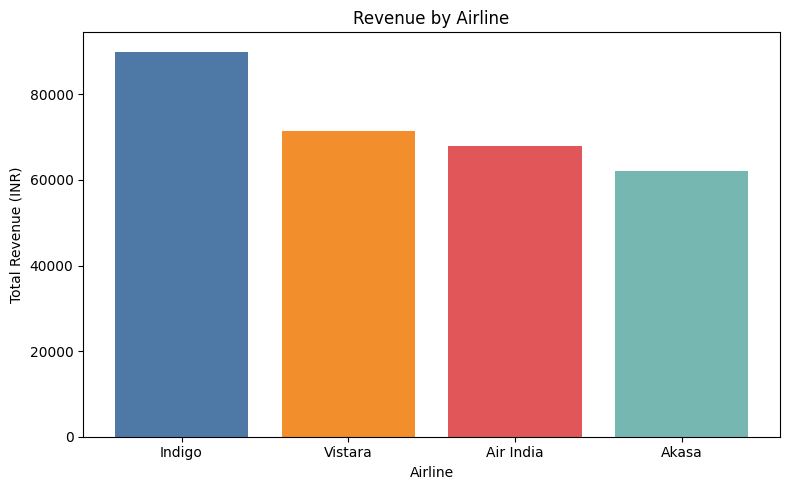

In [0]:
import matplotlib.pyplot as plt

airline_rev = bookings_pd.merge(flights_pd[["flight_id", "airline"]], on="flight_id")
airline_rev = airline_rev.groupby("airline")["ticket_price"].sum().reset_index()
airline_rev.columns = ["airline", "revenue"]
airline_rev = airline_rev.sort_values("revenue", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(airline_rev["airline"], airline_rev["revenue"], color=["#4e79a7", "#f28e2b", "#e15759", "#76b7b2"])
plt.title("Revenue by Airline")
plt.xlabel("Airline")
plt.ylabel("Total Revenue (INR)")
plt.tight_layout()
plt.show()

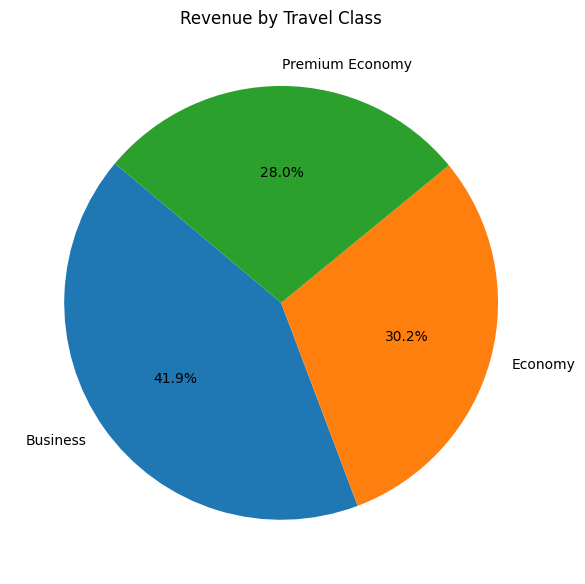

In [0]:
class_rev = bookings_pd.groupby("travel_class")["ticket_price"].sum()

plt.figure(figsize=(6, 6))
plt.pie(class_rev.values, labels=class_rev.index, autopct="%1.1f%%", startangle=140)
plt.title("Revenue by Travel Class")
plt.tight_layout()
plt.show()

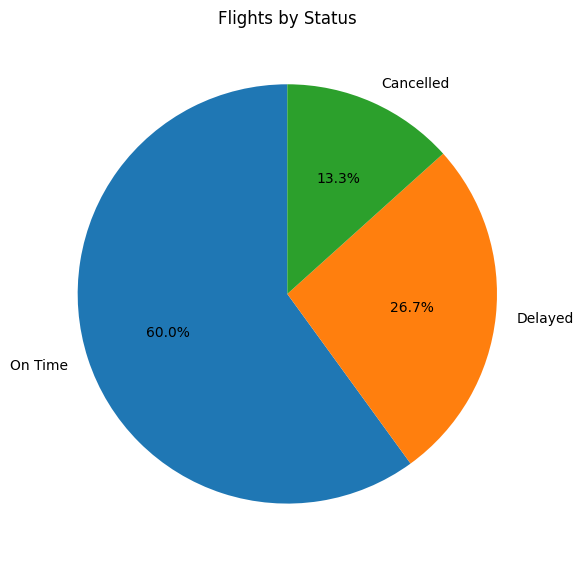

In [0]:
status_counts = flights_pd["status"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(status_counts.values, labels=status_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Flights by Status")
plt.tight_layout()
plt.show()

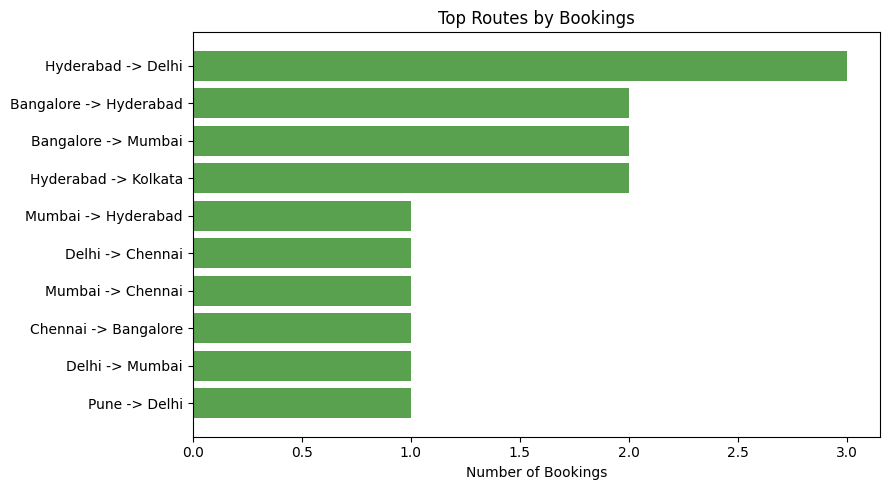

In [0]:
merged = bookings_pd.merge(flights_pd[["flight_id", "from_city", "to_city"]], on="flight_id")
merged["route"] = merged["from_city"] + " -> " + merged["to_city"]
route_counts = merged["route"].value_counts().head(10).sort_values()

plt.figure(figsize=(9, 5))
plt.barh(route_counts.index, route_counts.values, color="#59a14f")
plt.title("Top Routes by Bookings")
plt.xlabel("Number of Bookings")
plt.tight_layout()
plt.show()

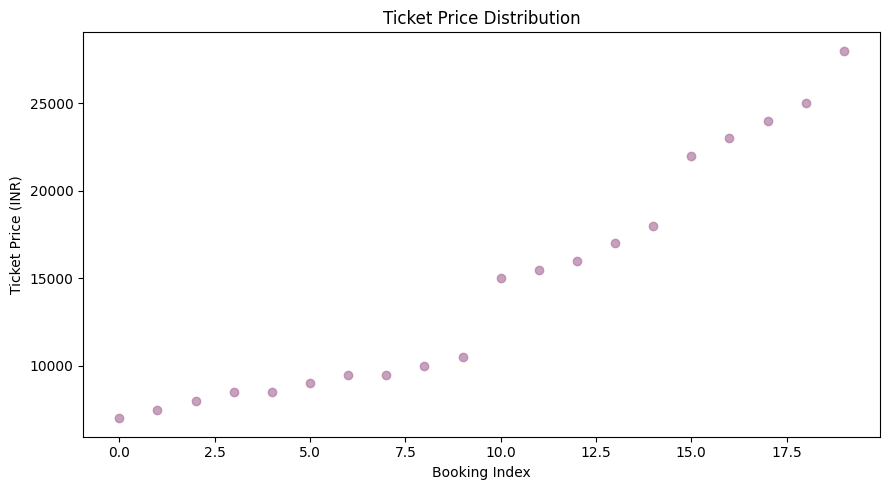

In [0]:
sorted_prices = bookings_pd.sort_values("ticket_price")["ticket_price"].reset_index(drop=True)

plt.figure(figsize=(9, 5))
plt.scatter(range(len(sorted_prices)), sorted_prices, color="#b07aa1", alpha=0.7)
plt.title("Ticket Price Distribution")
plt.xlabel("Booking Index")
plt.ylabel("Ticket Price (INR)")
plt.tight_layout()
plt.show()

In [0]:
journey_df = bookings_df \
    .join(flights_df, "flight_id", "inner") \
    .join(preferences_df, "passenger_name", "left")

journey_df.show()

+--------------+---------+----------+---------------+------------+------------+---------+---------+---------+--------+---------+-------------+-------+------+
|passenger_name|flight_id|booking_id|   travel_class|ticket_price|booking_date|  airline|from_city|  to_city|duration|   status|extra_baggage|   meal|  seat|
+--------------+---------+----------+---------------+------------+------------+---------+---------+---------+--------+---------+-------------+-------+------+
|  Rahul Sharma|     F101|     B1001|        Economy|        8500|  2026-06-01|   Indigo|Hyderabad|    Delhi|     140|  On Time|         true|    Veg|Window|
|   Priya Reddy|     F101|     B1002|       Business|       22000|  2026-06-01|   Indigo|Hyderabad|    Delhi|     140|  On Time|        false|Non-Veg| Aisle|
|    Amit Kumar|     F102|     B1003|        Economy|        9000|  2026-06-02|Air India|   Mumbai|  Chennai|     120|  Delayed|        false|    Veg|Middle|
|   Sneha Patel|     F103|     B1004|Premium Economy

In [0]:
from pyspark.sql.functions import col

journey_df = journey_df.withColumn(
    "revenue",
    col("ticket_price")
)

In [0]:
from pyspark.sql.functions import when

journey_df = journey_df.withColumn(
    "price_band",
    when(col("ticket_price") > 20000, "Premium")
    .when(col("ticket_price") > 10000, "Standard")
    .otherwise("Budget")
)

In [0]:
journey_df = journey_df.withColumn(
    "delay_flag",
    when(col("status") == "Delayed", "Yes")
    .otherwise("No")
)

In [0]:
journey_df.select(
    "booking_id",
    "flight_id",
    "passenger_name",
    "ticket_price",
    "revenue",
    "price_band",
    "status",
    "delay_flag"
).show()

+----------+---------+--------------+------------+-------+----------+---------+----------+
|booking_id|flight_id|passenger_name|ticket_price|revenue|price_band|   status|delay_flag|
+----------+---------+--------------+------------+-------+----------+---------+----------+
|     B1001|     F101|  Rahul Sharma|        8500|   8500|    Budget|  On Time|        No|
|     B1002|     F101|   Priya Reddy|       22000|  22000|   Premium|  On Time|        No|
|     B1003|     F102|    Amit Kumar|        9000|   9000|    Budget|  Delayed|       Yes|
|     B1004|     F103|   Sneha Patel|       15000|  15000|  Standard|  On Time|        No|
|     B1005|     F104|    Farhan Ali|        7500|   7500|    Budget|Cancelled|        No|
|     B1006|     F105|    Neha Singh|       25000|  25000|   Premium|  On Time|        No|
|     B1007|     F106|   Arjun Verma|       10000|  10000|    Budget|  Delayed|       Yes|
|     B1008|     F107|    Meera Nair|       17000|  17000|  Standard|  On Time|        No|

In [0]:
journey_df.createOrReplaceTempView("journey_data")

In [0]:
%sql

SELECT
    airline,
    SUM(revenue) AS total_revenue
FROM journey_data
GROUP BY airline
ORDER BY total_revenue DESC

airline,total_revenue
Indigo,90000
Vistara,71500
Air India,68000
Akasa,62000


In [0]:
%sql

SELECT
    from_city,
    to_city,
    SUM(revenue) AS route_revenue
FROM journey_data
GROUP BY from_city,to_city
ORDER BY route_revenue DESC

from_city,to_city,route_revenue
Hyderabad,Delhi,39000
Bangalore,Hyderabad,38000
Delhi,Chennai,28000
Hyderabad,Kolkata,26500
Chennai,Bangalore,25000
Chennai,Pune,24000
Bangalore,Mumbai,23500
Delhi,Hyderabad,18000
Hyderabad,Goa,16000
Kolkata,Bangalore,10500


In [0]:
%sql

SELECT
    ROUND(AVG(ticket_price),2) AS avg_ticket_price
FROM journey_data

avg_ticket_price
14575.0


In [0]:
%sql

SELECT
    to_city,
    COUNT(*) AS passengers
FROM journey_data
GROUP BY to_city
ORDER BY passengers DESC
LIMIT 1

to_city,passengers
Delhi,5


In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import *

In [0]:
flight_revenue = (
    journey_df
    .groupBy("flight_id")
    .agg(sum("revenue").alias("flight_revenue"))
)

window_spec = Window.orderBy(desc("flight_revenue"))

top_flights = (
    flight_revenue
    .withColumn("rank", rank().over(window_spec))
)

top_flights.filter(col("rank") <= 3).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+---------+--------------+----+
|flight_id|flight_revenue|rank|
+---------+--------------+----+
|     F101|         39000|   1|
|     F103|         38000|   2|
|     F109|         28000|   3|
+---------+--------------+----+



In [0]:
route_revenue = journey_df.groupBy(
    "airline",
    "from_city",
    "to_city"
).agg(
    sum("revenue").alias("route_revenue")
)

window_spec = Window.partitionBy(
    "airline"
).orderBy(
    desc("route_revenue")
)

route_revenue.withColumn(
    "rank",
    rank().over(window_spec)
).show()

+---------+---------+---------+-------------+----+
|  airline|from_city|  to_city|route_revenue|rank|
+---------+---------+---------+-------------+----+
|Air India|  Chennai|Bangalore|        25000|   1|
|Air India|Bangalore|   Mumbai|        23500|   2|
|Air India|  Kolkata|Bangalore|        10500|   3|
|Air India|   Mumbai|  Chennai|         9000|   4|
|    Akasa|    Delhi|  Chennai|        28000|   1|
|    Akasa|  Chennai|     Pune|        24000|   2|
|    Akasa|     Pune|    Delhi|        10000|   3|
|   Indigo|Hyderabad|    Delhi|        39000|   1|
|   Indigo|    Delhi|Hyderabad|        18000|   2|
|   Indigo|Hyderabad|      Goa|        16000|   3|
|   Indigo|   Mumbai|Hyderabad|         9500|   4|
|   Indigo|    Delhi|   Mumbai|         7500|   5|
|  Vistara|Bangalore|Hyderabad|        38000|   1|
|  Vistara|Hyderabad|  Kolkata|        26500|   2|
|  Vistara|      Goa|    Delhi|         7000|   3|
+---------+---------+---------+-------------+----+



In [0]:
window_spec = Window.orderBy("booking_date")

journey_df = journey_df.withColumn(
    "running_revenue",
    sum("revenue").over(window_spec)
)

journey_df.select(
    "booking_date",
    "revenue",
    "running_revenue"
).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+------------+-------+---------------+
|booking_date|revenue|running_revenue|
+------------+-------+---------------+
|  2026-06-01|   8500|          30500|
|  2026-06-01|  22000|          30500|
|  2026-06-02|   9000|          54500|
|  2026-06-02|  15000|          54500|
|  2026-06-03|   7500|          87000|
|  2026-06-03|  25000|          87000|
|  2026-06-04|  10000|         114000|
|  2026-06-04|  17000|         114000|
|  2026-06-05|   9500|         151500|
|  2026-06-05|  28000|         151500|
|  2026-06-06|   8000|         175500|
|  2026-06-06|  16000|         175500|
|  2026-06-07|   7000|         206500|
|  2026-06-07|  24000|         206500|
|  2026-06-08|  10500|         235000|
|  2026-06-08|  18000|         235000|
|  2026-06-09|   8500|         266500|
|  2026-06-09|  23000|         266500|
|  2026-06-10|   9500|         291500|
|  2026-06-10|  15500|         291500|
+------------+-------+---------------+



In [0]:
airline_revenue = journey_df.groupBy("airline") \
    .agg(sum("revenue").alias("total_revenue"))

window_spec = Window.orderBy(desc("total_revenue"))

airline_revenue.withColumn(
    "rank",
    rank().over(window_spec)
).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+---------+-------------+----+
|  airline|total_revenue|rank|
+---------+-------------+----+
|   Indigo|        90000|   1|
|  Vistara|        71500|   2|
|Air India|        68000|   3|
|    Akasa|        62000|   4|
+---------+-------------+----+



In [0]:
destination_df = journey_df.groupBy("to_city").count()

window_spec = Window.orderBy(desc("count"))

destination_df.withColumn(
    "dense_rank",
    dense_rank().over(window_spec)
).show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+---------+-----+----------+
|  to_city|count|dense_rank|
+---------+-----+----------+
|    Delhi|    5|         1|
|Hyderabad|    4|         2|
|   Mumbai|    3|         3|
|  Chennai|    2|         4|
|  Kolkata|    2|         4|
|Bangalore|    2|         4|
|     Pune|    1|         5|
|      Goa|    1|         5|
+---------+-----+----------+



In [0]:
journey_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("journey_master")

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
journey_df = spark.table("journey_master")

journey_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/tmp/delta/booking_master")

In [0]:
journey_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("booking_master")

In [0]:
spark.sql("""
    CREATE TABLE IF NOT EXISTS booking_master_sql
    USING DELTA
    AS
    SELECT * FROM journey_master
""")

DataFrame[num_affected_rows: bigint, num_inserted_rows: bigint]

In [0]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

day2_data = [
    ("B1021", "F102", "Ishaan Malik",   "Economy",         8800,  "2026-06-11"),
    ("B1022", "F105", "Kavitha Nair",   "Business",       26000,  "2026-06-11"),
    ("B1023", "F108", "Ravi Shankar",   "Economy",         9200,  "2026-06-12"),
    ("B1024", "F111", "Tanya Kapoor",   "Premium Economy", 16500,  "2026-06-12"),
    ("B1025", "F113", "Suresh Pillai",  "Economy",         7800,  "2026-06-13"),
    ("B1026", "F104", "Deepika Rao",    "Business",       21000,  "2026-06-13"),
    ("B1027", "F106", "Manish Tiwari",  "Economy",        10200,  "2026-06-14"),
    ("B1028", "F109", "Preethi Kumar",  "Premium Economy", 17500,  "2026-06-14"),
    ("B1029", "F112", "Harish Menon",   "Economy",         7200,  "2026-06-15"),
    ("B1030", "F115", "Swati Joshi",    "Business",       27000,  "2026-06-15"),
    ("B1001", "F101", "Rahul Sharma",   "Economy",         9000,  "2026-06-01"),
    ("B1003", "F102", "Amit Kumar",     "Economy",         9500,  "2026-06-02"),
    ("B1005", "F104", "Farhan Ali",     "Economy",         8000,  "2026-06-03"),
    ("B1007", "F106", "Arjun Verma",    "Economy",        10500,  "2026-06-04"),
    ("B1009", "F108", "Kiran Rao",      "Economy",        10000,  "2026-06-05"),
]

schema = StructType([
    StructField("booking_id",     StringType(),  True),
    StructField("flight_id",      StringType(),  True),
    StructField("passenger_name", StringType(),  True),
    StructField("travel_class",   StringType(),  True),
    StructField("ticket_price",   IntegerType(), True),
    StructField("booking_date",   StringType(),  True),
])

day2_df = spark.createDataFrame(day2_data, schema)
day2_df.show()

+----------+---------+--------------+---------------+------------+------------+
|booking_id|flight_id|passenger_name|   travel_class|ticket_price|booking_date|
+----------+---------+--------------+---------------+------------+------------+
|     B1021|     F102|  Ishaan Malik|        Economy|        8800|  2026-06-11|
|     B1022|     F105|  Kavitha Nair|       Business|       26000|  2026-06-11|
|     B1023|     F108|  Ravi Shankar|        Economy|        9200|  2026-06-12|
|     B1024|     F111|  Tanya Kapoor|Premium Economy|       16500|  2026-06-12|
|     B1025|     F113| Suresh Pillai|        Economy|        7800|  2026-06-13|
|     B1026|     F104|   Deepika Rao|       Business|       21000|  2026-06-13|
|     B1027|     F106| Manish Tiwari|        Economy|       10200|  2026-06-14|
|     B1028|     F109| Preethi Kumar|Premium Economy|       17500|  2026-06-14|
|     B1029|     F112|  Harish Menon|        Economy|        7200|  2026-06-15|
|     B1030|     F115|   Swati Joshi|   

In [0]:
from delta.tables import DeltaTable

booking_master = DeltaTable.forName(spark, "booking_master")

booking_master.alias("target").merge(
    day2_df.alias("source"),
    "target.booking_id = source.booking_id"
).whenMatchedUpdate(set={
    "ticket_price": "source.ticket_price"
}).whenNotMatchedInsert(values={
    "booking_id":     "source.booking_id",
    "flight_id":      "source.flight_id",
    "passenger_name": "source.passenger_name",
    "travel_class":   "source.travel_class",
    "ticket_price":   "source.ticket_price",
    "booking_date":   "source.booking_date",
}).execute()

print("Total rows after merge:", spark.table("booking_master").count())

Total rows after merge: 30


In [0]:
v0 = spark.read.format("delta").option("versionAsOf", 0).table("booking_master")
print("Version 0 row count:", v0.count())
v0.show(5)

Version 0 row count: 20
+--------------+---------+----------+---------------+------------+------------+---------+---------+---------+--------+---------+-------------+-------+------+-------+----------+----------+---------------+
|passenger_name|flight_id|booking_id|   travel_class|ticket_price|booking_date|  airline|from_city|  to_city|duration|   status|extra_baggage|   meal|  seat|revenue|price_band|delay_flag|running_revenue|
+--------------+---------+----------+---------------+------------+------------+---------+---------+---------+--------+---------+-------------+-------+------+-------+----------+----------+---------------+
|  Rahul Sharma|     F101|     B1001|        Economy|        8500|  2026-06-01|   Indigo|Hyderabad|    Delhi|     140|  On Time|         true|    Veg|Window|   8500|    Budget|        No|          30500|
|   Priya Reddy|     F101|     B1002|       Business|       22000|  2026-06-01|   Indigo|Hyderabad|    Delhi|     140|  On Time|        false|Non-Veg| Aisle|  2

In [0]:
v1 = spark.read.format("delta").option("versionAsOf", 1).table("booking_master")
print("Version 1 row count:", v1.count())
v1.show(5)

Version 1 row count: 30
+--------------+---------+----------+---------------+------------+------------+---------+---------+---------+--------+-------+-------------+-------+------+-------+----------+----------+---------------+
|passenger_name|flight_id|booking_id|   travel_class|ticket_price|booking_date|  airline|from_city|  to_city|duration| status|extra_baggage|   meal|  seat|revenue|price_band|delay_flag|running_revenue|
+--------------+---------+----------+---------------+------------+------------+---------+---------+---------+--------+-------+-------------+-------+------+-------+----------+----------+---------------+
|   Priya Reddy|     F101|     B1002|       Business|       22000|  2026-06-01|   Indigo|Hyderabad|    Delhi|     140|On Time|        false|Non-Veg| Aisle|  22000|   Premium|        No|          30500|
|   Sneha Patel|     F103|     B1004|Premium Economy|       15000|  2026-06-02|  Vistara|Bangalore|Hyderabad|      90|On Time|         true|   Jain|Window|  15000|  Sta

In [0]:

latest = spark.table("booking_master")
print("Latest row count:", latest.count())
latest.show(5)

Latest row count: 30
+--------------+---------+----------+---------------+------------+------------+---------+---------+---------+--------+-------+-------------+-------+------+-------+----------+----------+---------------+
|passenger_name|flight_id|booking_id|   travel_class|ticket_price|booking_date|  airline|from_city|  to_city|duration| status|extra_baggage|   meal|  seat|revenue|price_band|delay_flag|running_revenue|
+--------------+---------+----------+---------------+------------+------------+---------+---------+---------+--------+-------+-------------+-------+------+-------+----------+----------+---------------+
|   Priya Reddy|     F101|     B1002|       Business|       22000|  2026-06-01|   Indigo|Hyderabad|    Delhi|     140|On Time|        false|Non-Veg| Aisle|  22000|   Premium|        No|          30500|
|   Sneha Patel|     F103|     B1004|Premium Economy|       15000|  2026-06-02|  Vistara|Bangalore|Hyderabad|      90|On Time|         true|   Jain|Window|  15000|  Standa

In [0]:
print("B1001 before merge (Version 0):")
v0.filter("booking_id = 'B1001'").select("booking_id", "ticket_price").show()

print("B1001 after merge (Version 1):")
v1.filter("booking_id = 'B1001'").select("booking_id", "ticket_price").show()

B1001 before merge (Version 0):
+----------+------------+
|booking_id|ticket_price|
+----------+------------+
|     B1001|        8500|
+----------+------------+

B1001 after merge (Version 1):
+----------+------------+
|booking_id|ticket_price|
+----------+------------+
|     B1001|        9000|
+----------+------------+



In [0]:
spark.sql("OPTIMIZE booking_master")

spark.sql("OPTIMIZE booking_master ZORDER BY (flight_id)")

spark.sql("VACUUM booking_master")

spark.sql("DESCRIBE HISTORY booking_master")

DataFrame[version: bigint, timestamp: timestamp, userId: string, userName: string, operation: string, operationParameters: map<string,string>, job: struct<jobId:string,jobName:string,jobRunId:string,runId:string,jobOwnerId:string,triggerType:string>, notebook: struct<notebookId:string>, queryHistoryStatementId: string, clusterId: string, readVersion: bigint, isolationLevel: string, isBlindAppend: boolean, operationMetrics: map<string,string>, userMetadata: string, engineInfo: string]

In [0]:
journey_df = spark.table("journey_master")

journey_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("managed_booking_table")

print("Managed table created")

Managed table created


In [0]:
spark.table("booking_master").createOrReplaceTempView("booking_temp_view")

spark.sql("SELECT COUNT(*) AS total FROM booking_temp_view").show()

+-----+
|total|
+-----+
|   30|
+-----+

